## E0 — segment-length distribution per frame

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

In [2]:
DATA_PATH = r"../"   # <-- edit
REF_SECONDS  = 2

DATA_FILES = [
    (1,  'ha-1sec-full-rl-v4.pqt'),
    (2,  'ha-2sec-full-rl-v4.pqt'),
    (3,  'ha-3sec-full-rl-v4.pqt'),
    (4,  'ha-4sec-full-rl-v4.pqt'),
    (8,  'ha-8sec-full-rl-v4.pqt'),
    (16, 'ha-16sec-full-rl-v4.pqt'),
]

### Load

In [6]:
frames = {}
#for path in sorted(glob.glob(PARQUET_GLOB)):
for idx,(num, filename) in enumerate(DATA_FILES):
    print(num, filename)
    df = pd.read_parquet(DATA_PATH + filename)
    df['date'] = df['timestamp'].dt.normalize()
    n = num
    frames[n] = df
    print(f"{filename} -> n={n}s  rows={len(df):,}  days={df['date'].nunique()}")

ns = sorted(frames)

shared = set.intersection(*(set(frames[n]["date"].unique()) for n in ns))
print(f"\nshared days: {len(shared)}")

for n in ns:
    extra = frames[n]["date"].nunique() - len(shared)
    if extra:
        print(f"n={n}s: {extra} days not shared -> dropped")
    frames[n] = frames[n][frames[n]["date"].isin(shared)].reset_index(drop=True)

1 ha-1sec-full-rl-v4.pqt
ha-1sec-full-rl-v4.pqt -> n=1s  rows=27,627,765  days=1158
2 ha-2sec-full-rl-v4.pqt
ha-2sec-full-rl-v4.pqt -> n=2s  rows=14,256,735  days=1158
3 ha-3sec-full-rl-v4.pqt
ha-3sec-full-rl-v4.pqt -> n=3s  rows=9,572,766  days=1158
4 ha-4sec-full-rl-v4.pqt
ha-4sec-full-rl-v4.pqt -> n=4s  rows=7,193,919  days=1157
8 ha-8sec-full-rl-v4.pqt
ha-8sec-full-rl-v4.pqt -> n=8s  rows=3,594,459  days=1155
16 ha-16sec-full-rl-v4.pqt
ha-16sec-full-rl-v4.pqt -> n=16s  rows=1,788,654  days=1155

shared days: 1155
n=1s: 3 days not shared -> dropped
n=2s: 3 days not shared -> dropped
n=3s: 3 days not shared -> dropped
n=4s: 2 days not shared -> dropped


### Segment

In [7]:
def add_segments(df):
    date = df["date"].to_numpy()
    s = pd.Series(np.sign(df["jmaD1"].to_numpy())).replace(0.0, np.nan)
    s = s.groupby(date).ffill().groupby(date).bfill().to_numpy()

    m = len(df)
    new_day = np.empty(m, dtype=bool); new_day[0] = True
    new_day[1:] = date[1:] != date[:-1]
    flip = np.empty(m, dtype=bool); flip[0] = True
    flip[1:] = s[1:] != s[:-1]

    df["segSign"] = s.astype("int8")
    df["segId"] = np.cumsum(new_day | flip)
    df["g"] = df.groupby("segId").cumcount() + 1
    df["segLen"] = df.groupby("segId")["g"].transform("size")
    df["remaining"] = df["segLen"] - df["g"]
    return df

for n in ns:
    frames[n] = add_segments(frames[n])

seglen = {n: frames[n].groupby("segId").size() for n in ns}

### Stats

In [8]:
rows = []
for n in ns:
    L = seglen[n]
    days = len(shared)
    rows.append({
        "n_s": n, "days": days,
        "bars/day": round(len(frames[n]) / days),
        "segs/day": round(len(L) / days, 1),
        "min": int(L.min()),
        "p25": L.quantile(.25), "med": L.quantile(.5),
        "p75": L.quantile(.75), "p90": L.quantile(.9), "p99": L.quantile(.99),
        "max": int(L.max()),
        "mean": round(L.mean(), 2), "std": round(L.std(), 2),
    })
e0 = pd.DataFrame(rows).set_index("n_s")
e0

,days,bars/day,segs/day,min,p25,med,p75,p90,p99,max,mean,std
n_s,,,,,,,,,,,,
1,1155,23906,2491.3,1,5.0,8.0,13.0,19.0,35.0,111,9.60,7.30
2,1155,12335,1278.6,1,5.0,8.0,13.0,19.0,35.0,112,9.65,7.36
3,1155,8282,857.7,1,5.0,8.0,13.0,19.0,35.0,115,9.66,7.38
4,1155,6225,643.9,1,5.0,8.0,13.0,19.0,35.0,103,9.67,7.39
8,1155,3112,321.2,1,5.0,8.0,13.0,19.0,36.0,98,9.69,7.44
16,1155,1549,160.7,1,4.0,8.0,13.0,19.0,36.0,94,9.64,7.47


### KS vs reference, ECDF overlay

In [9]:
ref = seglen[REF_SECONDS].to_numpy()

rng = np.random.default_rng(0)
floor = np.array([
    ks_2samp(*np.array_split(rng.permutation(ref), 2)).statistic
    for _ in range(200)
])
print(f"sampling floor (split-half {REF_SECONDS}s): D mean={floor.mean():.4f}  p95={np.quantile(floor, .95):.4f}\n")

for n in ns:
    if n == REF_SECONDS:
        continue
    D = ks_2samp(seglen[n].to_numpy(), ref).statistic
    print(f"n={n:>2}s vs {REF_SECONDS}s: D={D:.4f}  (N={len(seglen[n]):,})")

sampling floor (split-half 2s): D mean=0.0012  p95=0.0020

n= 1s vs 2s: D=0.0026  (N=2,877,483)
n= 3s vs 2s: D=0.0016  (N=990,689)
n= 4s vs 2s: D=0.0026  (N=743,716)
n= 8s vs 2s: D=0.0031  (N=370,945)
n=16s vs 2s: D=0.0080  (N=185,616)


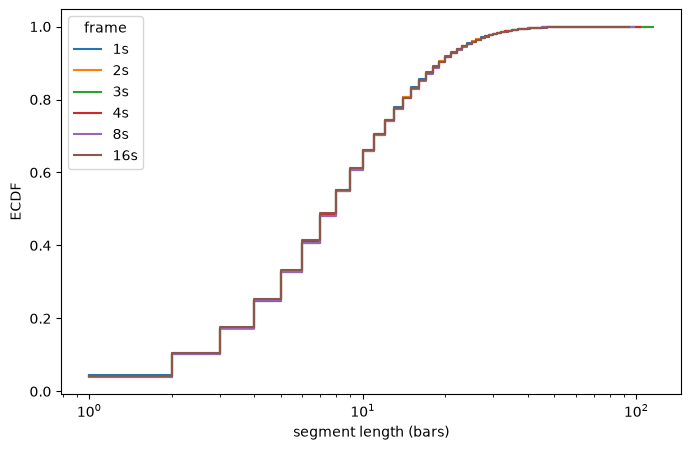

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for n in ns:
    L = np.sort(seglen[n].to_numpy())
    xs = np.arange(1, L[-1] + 1)
    ax.step(xs, np.searchsorted(L, xs, side="right") / len(L), where="post", label=f"{n}s")
ax.set_xscale("log")
ax.set_xlabel("segment length (bars)")
ax.set_ylabel("ECDF")
ax.legend(title="frame")
plt.show()